Helper Code 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# our helper for the whole session: draw a shape before and after a transformation.
# a shape is stored as a 2 x N array -- each COLUMN is a point.
def show_transform(matrix, title=""):
    # a unit square plus a diagonal, so we can see rotation and flips clearly
    shape = np.array([[0, 1, 1, 0, 0, 1],
                      [0, 0, 1, 1, 0, 1]], dtype=float)
    transformed = matrix @ shape        # THE transformation: one matrix multiply

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, pts, ttl, col in [(axes[0], shape, "before", "#5F5F60"),
                              (axes[1], transformed, "after", "#F05E22")]:
        ax.plot(pts[0], pts[1], "-o", color=col, linewidth=2)
        ax.fill(pts[0], pts[1], color=col, alpha=0.15)
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
        ax.axhline(0, color="#ccc", lw=0.8); ax.axvline(0, color="#ccc", lw=0.8)
        ax.grid(alpha=0.3); ax.set_title(ttl)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
    det = np.linalg.det(matrix)
    print(f'determinant: {det:.2f}')

def rotation(deg):
    t = np.radians(deg)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

def is_invertible(m):
    return not np.isclose(np.linalg.det(m), 0)
    
print("helper ready -- give it a 2x2 matrix and watch a shape transform")

helper ready -- give it a 2x2 matrix and watch a shape transform


In [2]:
# import numpy as np
# import matplotlib.pyplot as plt

# shape = np.array([[0,1,1,0,0],
#                   [0,0,1,1,0]], dtype=float)

# def rotation(deg):
#     t = np.radians(deg)
#     return np.array([[np.cos(t), -np.sin(t)],
#                      [np.sin(t),  np.cos(t)]])



Scaling: apply [[2,0],[0,0.5]]. Which axis stretches, which squishes?

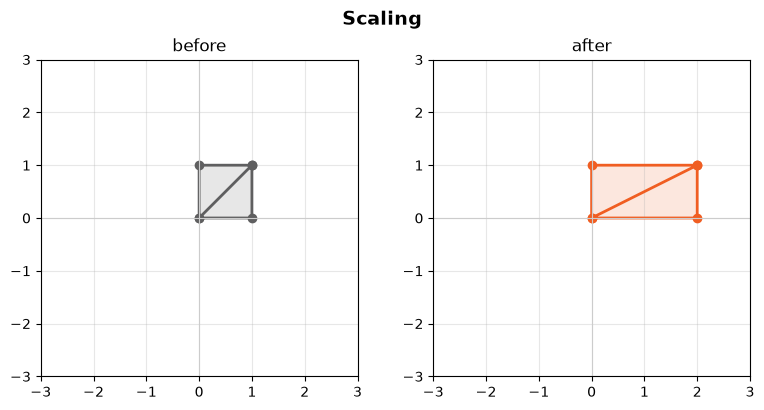

determinant: 2.00
True


In [3]:
show_transform(np.array([[2, 0],
                         [0, 1]]), "Scaling")
print(is_invertible(np.array([[2, 0],
                         [0, 1]])))

Rotation: write a rotation(degrees) function and rotate the shape by 30, 90, and 180 degrees

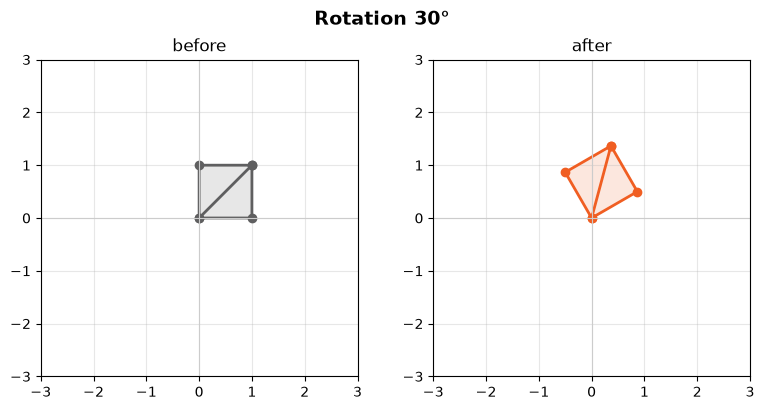

determinant: 1.00


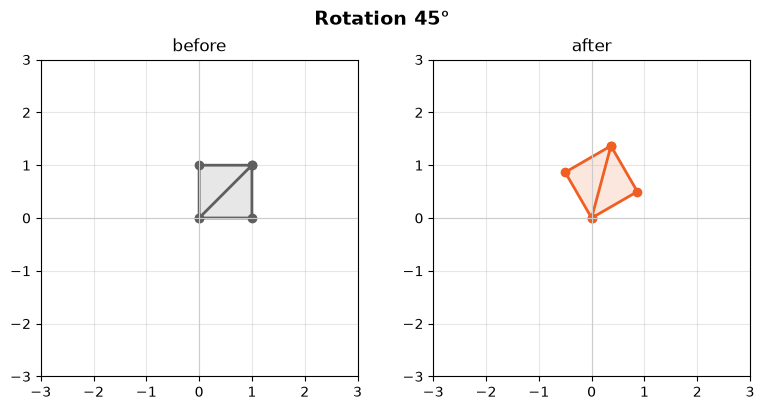

determinant: 1.00


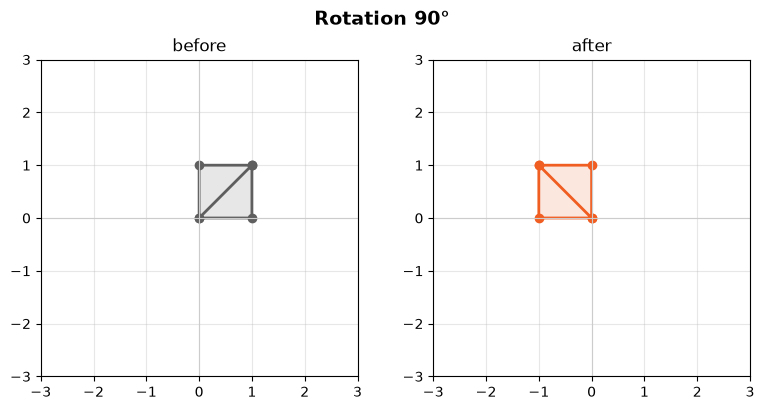

determinant: 1.00


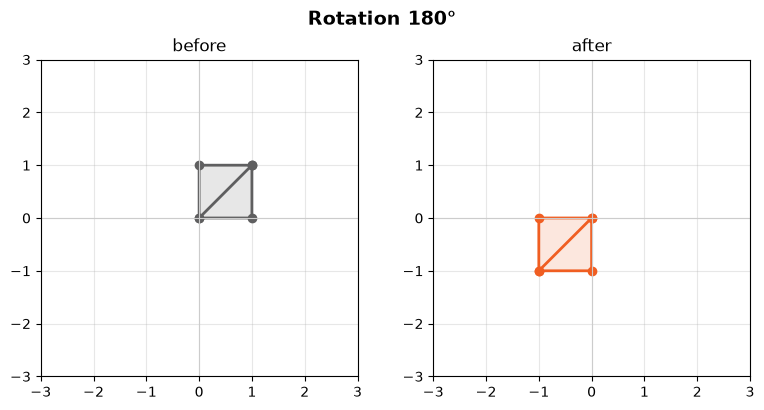

determinant: 1.00
True
True
True
True


In [4]:
def rotation(deg):
    t = np.radians(deg)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

show_transform(rotation(30), "Rotation 30°")
show_transform(rotation(30), "Rotation 45°")
show_transform(rotation(90), "Rotation 90°")
show_transform(rotation(180), "Rotation 180°")

print(is_invertible(rotation(30)))
print(is_invertible(rotation(45)))
print(is_invertible(rotation(90)))
print(is_invertible(rotation(180)))

Shear: apply [[1,1],[0,1]]. Confirm the square becomes a parallelogram

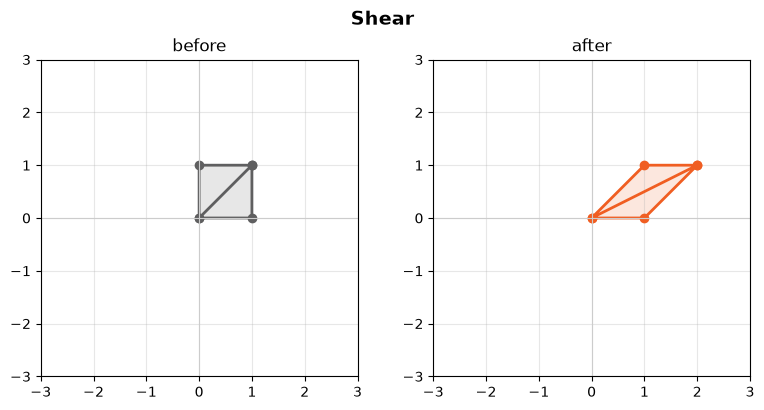

determinant: 1.00
True


In [5]:
show_transform(np.array([[1, 1],
                         [0, 1]]), "Shear")


print(is_invertible(np.array([[1, 1],
                         [0, 1]])))

Reflection: flip the shape across the x-axis, then across the y-axis. Use a non-symmetric shape so the flip is
visible

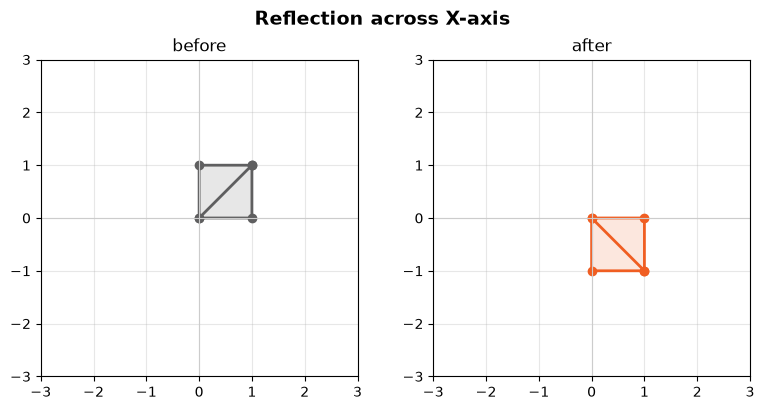

determinant: -1.00
True


In [6]:
show_transform(np.array([[1, 0],
                         [0, -1]]), "Reflection across X-axis")



print(is_invertible(np.array([[1, 0],
                         [0, -1]])))

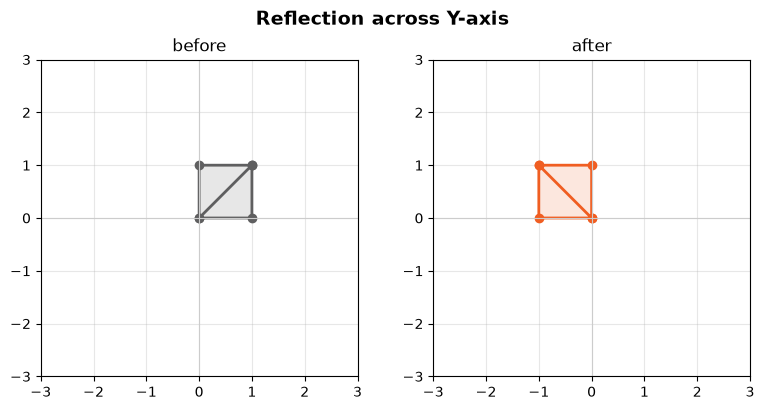

determinant: -1.00
True


In [7]:
show_transform(np.array([[-1, 0],
                         [0, 1]]), "Reflection across Y-axis")

print(is_invertible(np.array([[-1, 0],
                         [0, 1]])))

TASK 02
Compute determinants and check invertibility

### added code in the starter code and get the all determinant as per things 

Build a singular matrix — make the second column a multiple of the first. Compute its determinant (it should be
zero) and apply it to your shape. What happens to the square?

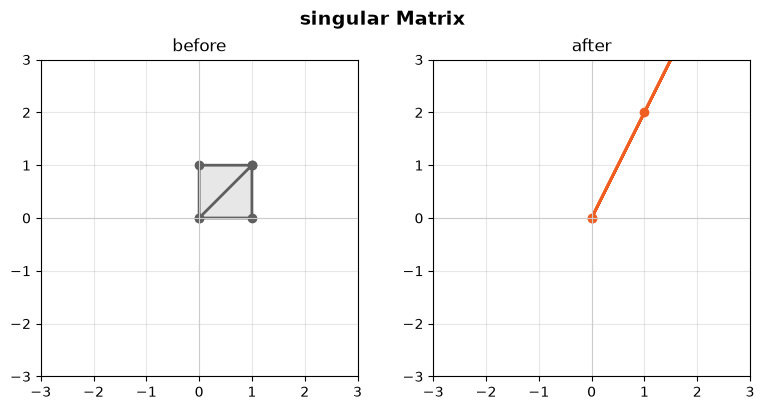

determinant: 0.00
False

Inverse Error: Singular matrix


In [8]:
sing = np.array([[1., 2.], [2., 4.]])

show_transform(sing , "singular Matrix")

print(is_invertible(np.array([[1., 2.], [2., 4.]])))

try:
    np.linalg.inv(sing)
except np.linalg.LinAlgError as e:
    print("\nInverse Error:", e)

TASK 03
Verify associativity: (AB)C = A(BC)

Create three different 2×2 matrices A, B, C — mix a rotation, a scaling, and a shear.

In [9]:
import numpy as np

# A: Rotation (45°)
A = np.array([[np.cos(np.radians(45)), -np.sin(np.radians(45))],
              [np.sin(np.radians(45)),  np.cos(np.radians(45))]])

# B: Scaling
B = np.array([[2, 0],
              [0, 0.5]])

# C: Shear
C = np.array([[1, 1],
              [0, 1]])

In [10]:
left = (A @ B) @ C
right = A @ (B @ C)
print('associative?', np.allclose(left, right))

associative? True


In [11]:
print('commutative?', np.allclose(A @ B, B @ A))


commutative? False


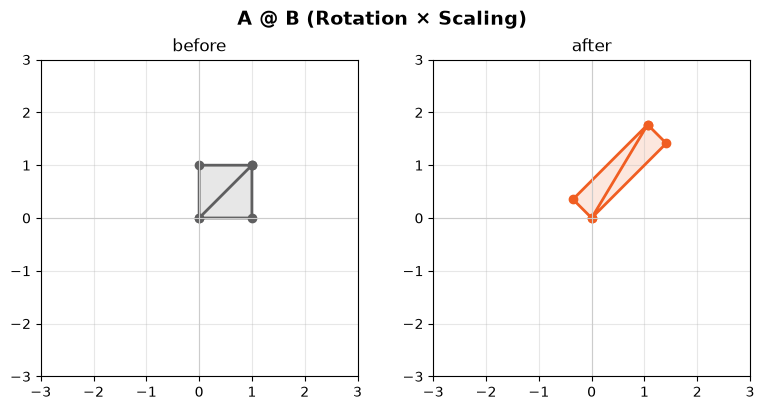

determinant: 1.00


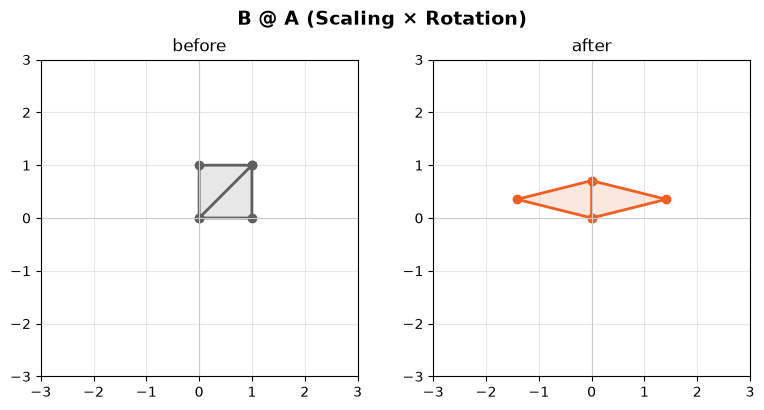

determinant: 1.00


In [12]:
show_transform(A @ B, "A @ B (Rotation × Scaling)")

# Apply Scaling then Rotation
show_transform(B @ A, "B @ A (Scaling × Rotation)")

TASK 04
Compose a sequence of transformations

• Take your shape and apply, in order: scale by 1.5, then rotate 45 degrees, then shear. Build each as a matrix.

• Combine them into a single matrix by multiplying — remember the first-applied goes on the right.

• Confirm that applying the combined matrix in one step gives the same result as applying the three separately,
one after another.

• Plot the shape at each stage of the sequence, so you can see it transform step by step.

• Compute the determinant of the combined matrix. Show it equals the product of the three individual
determinants.

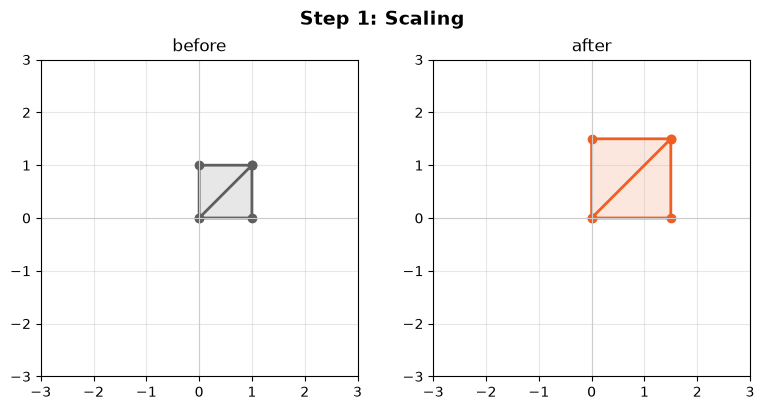

determinant: 2.25


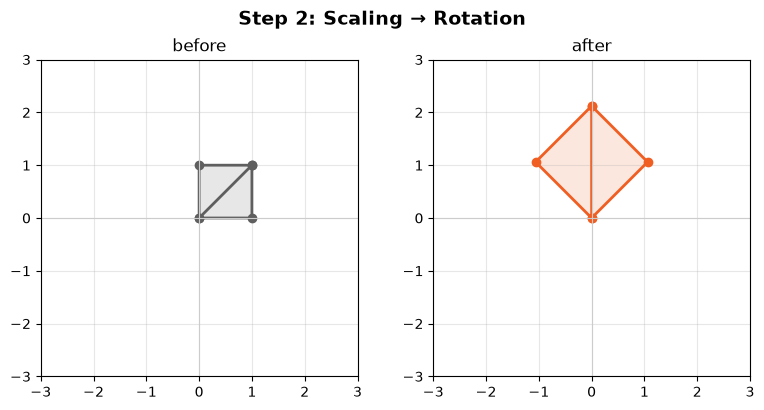

determinant: 2.25


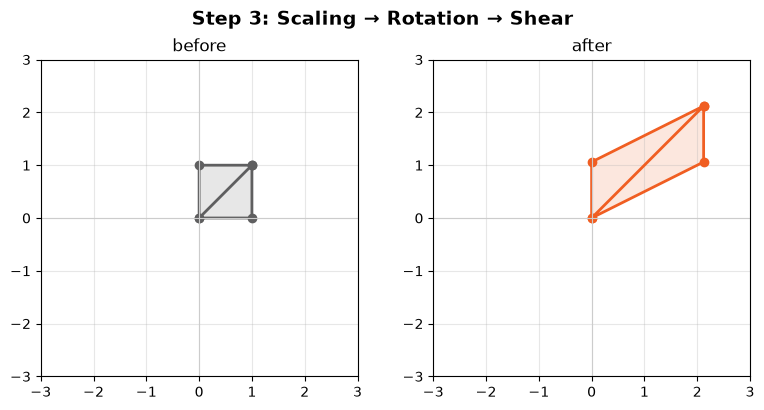

determinant: 2.25


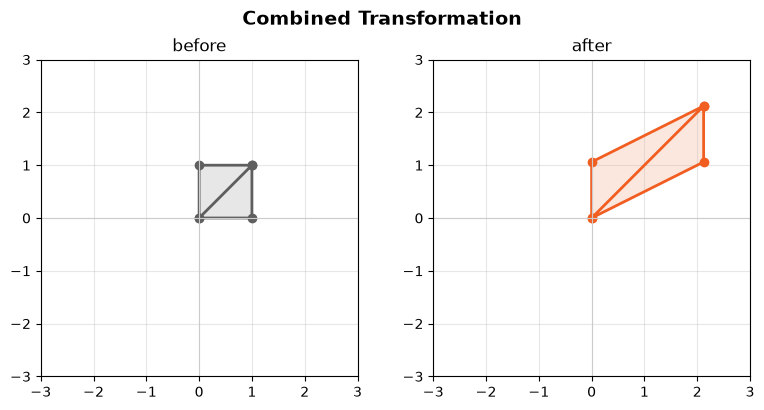

determinant: 2.25


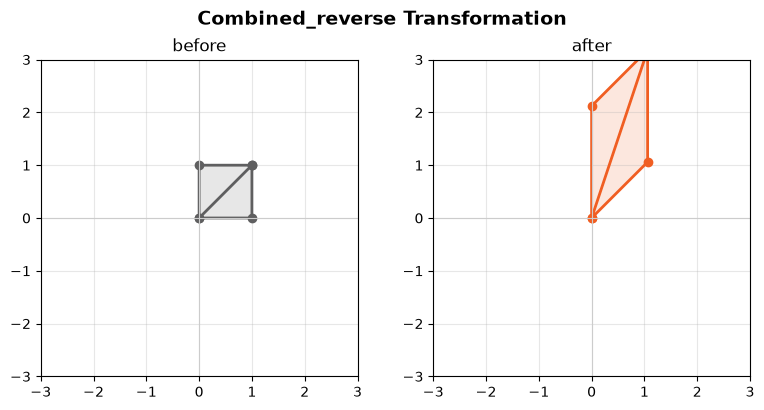

determinant: 2.25


In [13]:
import numpy as np

# Scaling
S = np.array([[1.5, 0],
              [0, 1.5]])

# Rotation (45°)
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Shear
H = np.array([[1, 1],
              [0, 1]])

# Plot each stage
show_transform(S, "Step 1: Scaling")
show_transform(R @ S, "Step 2: Scaling → Rotation")
show_transform(H @ R @ S, "Step 3: Scaling → Rotation → Shear")

# Combined matrix
combined = H @ R @ S

combined_reversed = S @ R @ H

show_transform(combined, "Combined Transformation")
show_transform(combined_reversed, "Combined_reverse Transformation")

TASK 05
Special matrices and their properties

Build a diagonal matrix and confirm it only scales, never rotates (apply it and look).

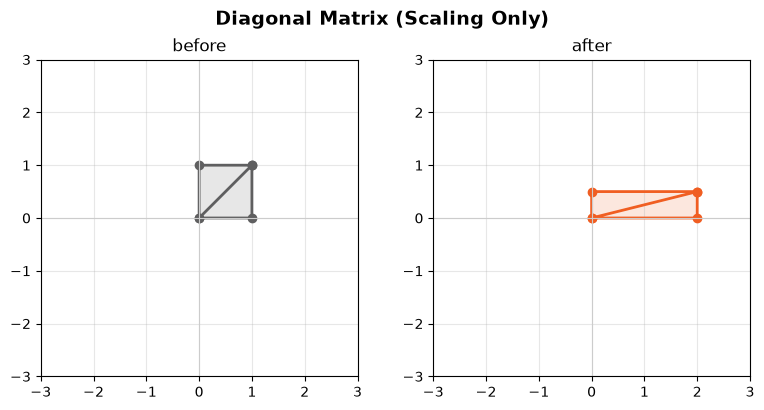

determinant: 1.00


In [14]:
import numpy as np

# 1. Diagonal Matrix (Scaling only)
D = np.array([[2, 0],
              [0, 0.5]])

show_transform(D, "Diagonal Matrix (Scaling Only)")

Build a symmetric matrix (equal to its transpose) and verify A == A.T.

In [15]:
A = np.array([[2, 1],
              [1, 3]])

print("Symmetric Matrix:")
print(A)
print("\nA == A.T ?")
print(np.array_equal(A, A.T))


Symmetric Matrix:
[[2 1]
 [1 3]]

A == A.T ?
True


 Build an orthogonal matrix (any rotation works) and verify Q.T @ Q is the identity.


Orthogonal Matrix:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Q.T @ Q =
[[ 1.00000000e+00 -4.26642159e-17]
 [-4.26642159e-17  1.00000000e+00]]

Is Identity?
True


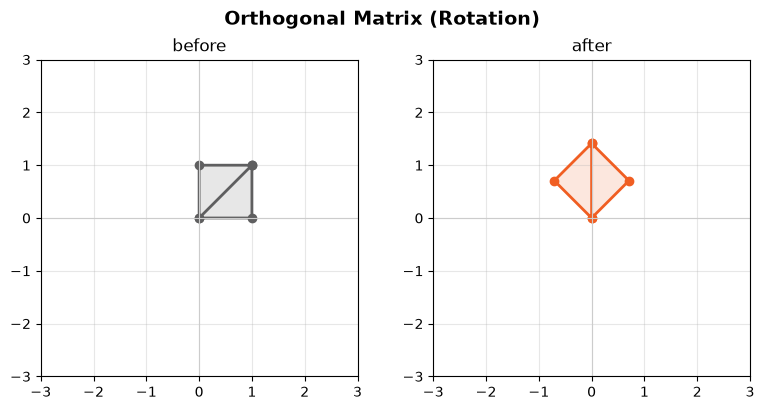

determinant: 1.00


In [16]:
theta = np.radians(45)

Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

print("\nOrthogonal Matrix:")
print(Q)

print("\nQ.T @ Q =")
print(Q.T @ Q)

print("\nIs Identity?")
print(np.allclose(Q.T @ Q, np.eye(2)))

show_transform(Q, "Orthogonal Matrix (Rotation)")

Prove the orthogonal matrix preserves lengths: pick a vector, and show norm(Q @ v) == norm(v).

In [17]:
v = np.array([3, 4])

print("\nOriginal Length:", np.linalg.norm(v))
print("After Rotation:", np.linalg.norm(Q @ v))

print("Length Preserved:",
      np.isclose(np.linalg.norm(v), np.linalg.norm(Q @ v)))


Original Length: 5.0
After Rotation: 5.0
Length Preserved: True


Prove it preserves angles: pick two vectors, and show the angle between them is unchanged after applying Q.

In [18]:
a = np.array([1, 2])
b = np.array([3, 1])

def angle(x, y):
    return np.degrees(
        np.arccos(
            np.dot(x, y) /
            (np.linalg.norm(x) * np.linalg.norm(y))
        )
    )

original_angle = angle(a, b)
new_angle = angle(Q @ a, Q @ b)

print("\nOriginal Angle:", original_angle)
print("After Rotation:", new_angle)

print("Angle Preserved:",
      np.isclose(original_angle, new_angle))



Original Angle: 45.00000000000001
After Rotation: 45.0
Angle Preserved: True


TASK 06
An interactive transformation explorer

Write a function explore(a, b, c, d) that takes the four entries of a 2×2 matrix, applies it to a shape, and
displays: the before/after plot, where the two basis vectors land, and the determinant.

• Use it to answer, by experiment: what values give a pure rotation? A pure scaling? A reflection?

• Find a matrix whose determinant is negative but whose scaling looks 'normal'. What did the negative sign
correspond to visually?

• Find, by trial, a set of four numbers that collapses the square to a line. Verify the determinant is zero.

• Make a small table: five matrices you tried, what they did to the shape, and their determinants. This is your
reference card.

Matrix: [[2 0]
 [0 2]]
Determinant: 4.00


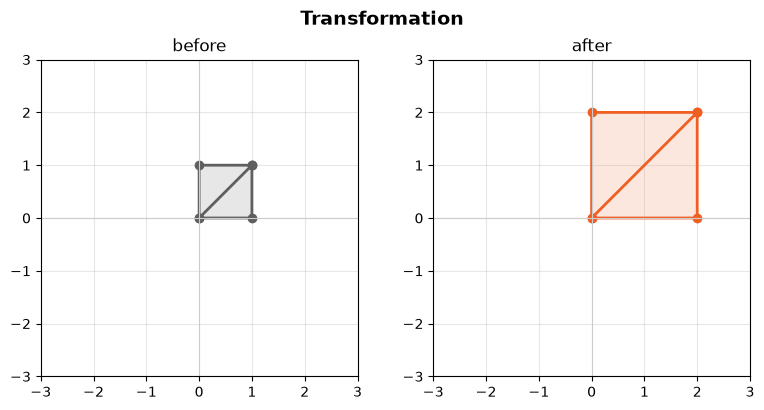

determinant: 4.00
e1 → [2 0]
e2 → [0 2]


In [19]:
import numpy as np

def explore(a, b, c, d):
    M = np.array([[a, b],
                  [c, d]])

    det = np.linalg.det(M)

    print("Matrix:" , M)
    print(f"Determinant: {det:.2f}")

    # Show transformed shape
    show_transform(M, "Transformation")

    # Show where basis vectors land
    e1 = np.array([1, 0])
    e2 = np.array([0, 1])

    print("e1 →", M @ e1)
    print("e2 →", M @ e2)

explore(2, 0,
        0, 2)